# Coverage of the Arthouse Cohort
## From Analytics to Action — DTU Spring 2026

**Working set:** the final arthouse cohort from `arthouse_cohort.csv` — the union of the rule-based filter and the LLM scorer at `arthouse_score >= 8` (see `build_cohort.py`).

**Question:** for the films we *do* care about, how many have the data we'd need for a real analysis — IMDb ratings, plot text, budget/revenue, MovieLens ratings?

## 1. Load the cohort

In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / '03-data').exists() and (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
os.chdir(PROJECT_ROOT)

df = pd.read_csv('notebooks/arthouse/arthouse-analysis/arthouse_cohort.csv')

print(f'Cohort films: {len(df):,}')

source_dist = df['arthouse_source'].value_counts().rename_axis('arthouse_source').to_frame('films')
source_dist['pct'] = (source_dist['films'] / len(df) * 100).round(1)
display(source_dist)

Cohort films: 4,191


,films,pct
arthouse_source,,
llm_only,3516,83.9
rule_only,481,11.5
both,194,4.6


## 2. Coverage of the main signals

Six things we're likely to want for the next analysis.

In [2]:
signals = {
    'IMDb rating':        df['imdbRating'].notna(),
    'Plot summary':       df['plotShort'].notna() | df['plotMedium'].notna() | df['plotLong'].notna(),
    'Keywords':           df['keywords'].notna(),
    'TMDB budget':        df['budget'].notna() & (df['budget'] != 0),
    'TMDB revenue':       df['revenue'].notna() & (df['revenue'] != 0),
    'MovieLens ratings':  df['ml_rating_count'].notna() & (df['ml_rating_count'] > 0),
}

coverage = pd.DataFrame({
    'films_with': [int(m.sum()) for m in signals.values()],
    'pct':        [round(m.mean() * 100, 1) for m in signals.values()],
}, index=list(signals.keys())).rename_axis('signal')
display(coverage)

,films_with,pct
signal,,
IMDb rating,2684,64.0
Plot summary,3080,73.5
Keywords,2715,64.8
TMDB budget,222,5.3
TMDB revenue,194,4.6
MovieLens ratings,61,1.5


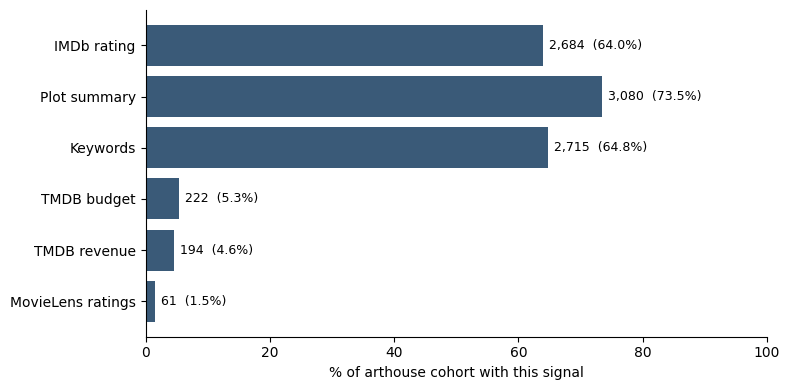

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coverage.index, coverage['pct'], color='#3a5a78')
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% of arthouse cohort with this signal')
for i, (n, p) in enumerate(zip(coverage['films_with'], coverage['pct'])):
    ax.text(p + 1, i, f'{n:,}  ({p}%)', va='center', fontsize=9)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Joint coverage

How many cohort films have the *combinations* a real analysis needs.

In [4]:
combos = {
    'rating + budget':           signals['IMDb rating'] & signals['TMDB budget'],
    'rating + revenue':          signals['IMDb rating'] & signals['TMDB revenue'],
    'budget + revenue':          signals['TMDB budget'] & signals['TMDB revenue'],
    'rating + plot + keywords':  signals['IMDb rating'] & signals['Plot summary'] & signals['Keywords'],
}
joint = pd.DataFrame({
    'films': [int(m.sum()) for m in combos.values()],
    'pct':   [round(m.mean() * 100, 1) for m in combos.values()],
}, index=list(combos.keys())).rename_axis('combination')
display(joint)

,films,pct
combination,,
rating + budget,213,5.1
rating + revenue,194,4.6
budget + revenue,94,2.2
rating + plot + keywords,1998,47.7


## 4. Coverage by cohort source

Are rule-only picks (foreign-language / festival-circuit films) systematically thinner on metadata than LLM-picked films?

In [5]:
by_source = (
    pd.DataFrame({name: mask for name, mask in signals.items()})
    .assign(arthouse_source=df['arthouse_source'].values)
    .groupby('arthouse_source')
    .mean()
    .mul(100)
    .round(1)
)
by_source.insert(0, 'films', df['arthouse_source'].value_counts())
display(by_source)

,films,IMDb rating,Plot summary,Keywords,TMDB budget,TMDB revenue,MovieLens ratings
arthouse_source,,,,,,,
both,194,100.0,96.9,92.8,13.9,14.4,3.6
llm_only,3516,57.1,69.5,59.4,2.7,2.8,1.0
rule_only,481,100.0,93.3,93.1,20.6,13.9,4.0


## 5. Takeaway

Read off the numbers above to decide which angle is viable on this dataset.